In [146]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score,classification_report,confusion_matrix,roc_auc_score,roc_curve)

In [147]:
data=pd.read_excel("/content/default of credit card clients.xls")

In [148]:
data.head(10)

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0
5,6,50000,1,1,2,37,0,0,0,0,...,19394,19619,20024,2500,1815,657,1000,1000,800,0
6,7,500000,1,1,2,29,0,0,0,0,...,542653,483003,473944,55000,40000,38000,20239,13750,13770,0
7,8,100000,2,2,2,23,0,-1,-1,0,...,221,-159,567,380,601,0,581,1687,1542,0
8,9,140000,2,3,1,28,0,0,2,0,...,12211,11793,3719,3329,0,432,1000,1000,1000,0
9,10,20000,1,3,2,35,-2,-2,-2,-2,...,0,13007,13912,0,0,0,13007,1122,0,0


In [149]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   ID                          30000 non-null  int64
 1   LIMIT_BAL                   30000 non-null  int64
 2   SEX                         30000 non-null  int64
 3   EDUCATION                   30000 non-null  int64
 4   MARRIAGE                    30000 non-null  int64
 5   AGE                         30000 non-null  int64
 6   PAY_0                       30000 non-null  int64
 7   PAY_2                       30000 non-null  int64
 8   PAY_3                       30000 non-null  int64
 9   PAY_4                       30000 non-null  int64
 10  PAY_5                       30000 non-null  int64
 11  PAY_6                       30000 non-null  int64
 12  BILL_AMT1                   30000 non-null  int64
 13  BILL_AMT2                   30000 non-null  int64
 14  BILL_A

In [150]:
print("Shape:", data.shape)

Shape: (30000, 25)


In [151]:
data.describe()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,15000.500000,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,8660.398374,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,1.000000,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,7500.750000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,15000.500000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,22500.250000,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,30000.000000,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


In [152]:
print("Missing values total:", data.isnull().sum().sum())

Missing values total: 0


In [153]:
print("Duplicates total:", data.duplicated().sum())

Duplicates total: 0


In [154]:
data.columns

Index(['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'default payment next month'],
      dtype='object')

In [155]:
data['default payment next month'].value_counts(normalize=True)

,proportion
default payment next month,
0,0.7788
1,0.2212


In [156]:
target = 'default payment next month'

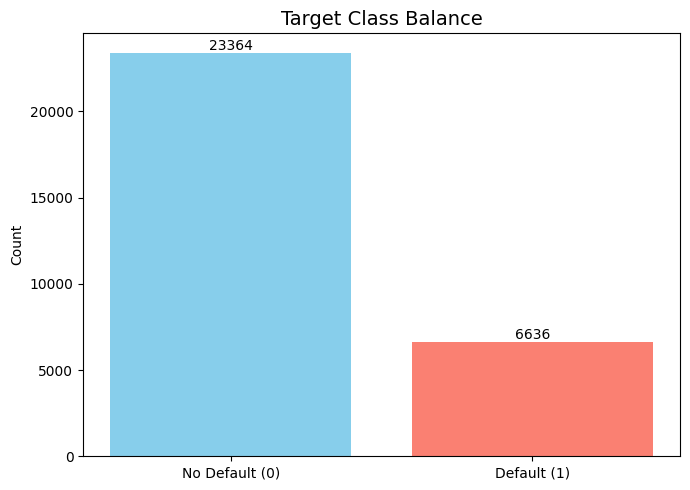

In [157]:
# توزيع فئات الهدف (Target Class Balance)
class_counts = data[target].value_counts().sort_index()
plt.figure(figsize=(7, 5))
bars = plt.bar(['No Default (0)', 'Default (1)'], class_counts.values, color=['skyblue', 'salmon'])
plt.title('Target Class Balance', fontsize=14)
plt.ylabel('Count')
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height, f'{int(height)}', ha='center', va='bottom')
plt.tight_layout()
plt.show()

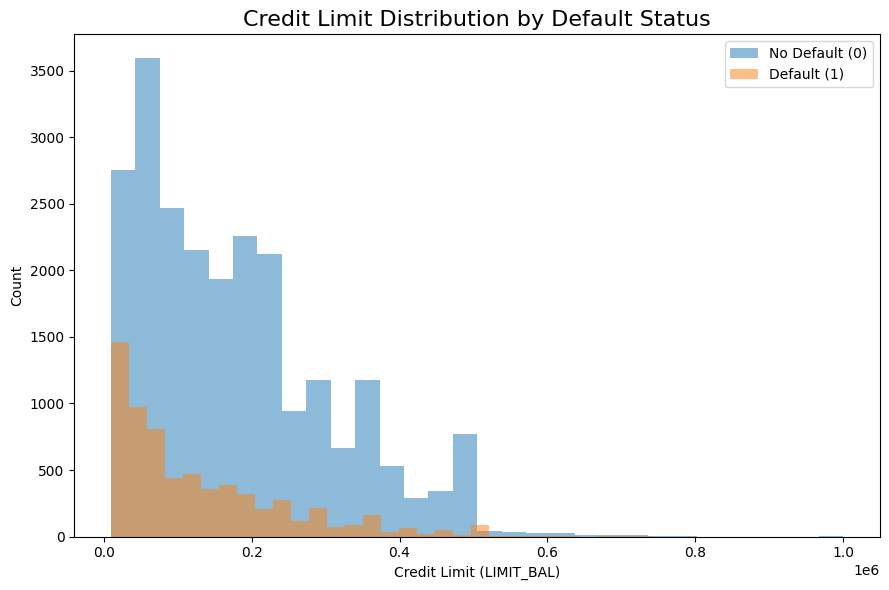

In [158]:
plt.figure(figsize=(9, 6))

plt.hist(
    data.loc[data[target] == 0, 'LIMIT_BAL'],
    bins=30,
    alpha=0.5,
    label='No Default (0)'
)

plt.hist(
    data.loc[data[target] == 1, 'LIMIT_BAL'],
    bins=30,
    alpha=0.5,
    label='Default (1)'
)

plt.title('Credit Limit Distribution by Default Status', fontsize=16)
plt.xlabel('Credit Limit (LIMIT_BAL)')
plt.ylabel('Count')
plt.legend()

plt.tight_layout()
plt.show()

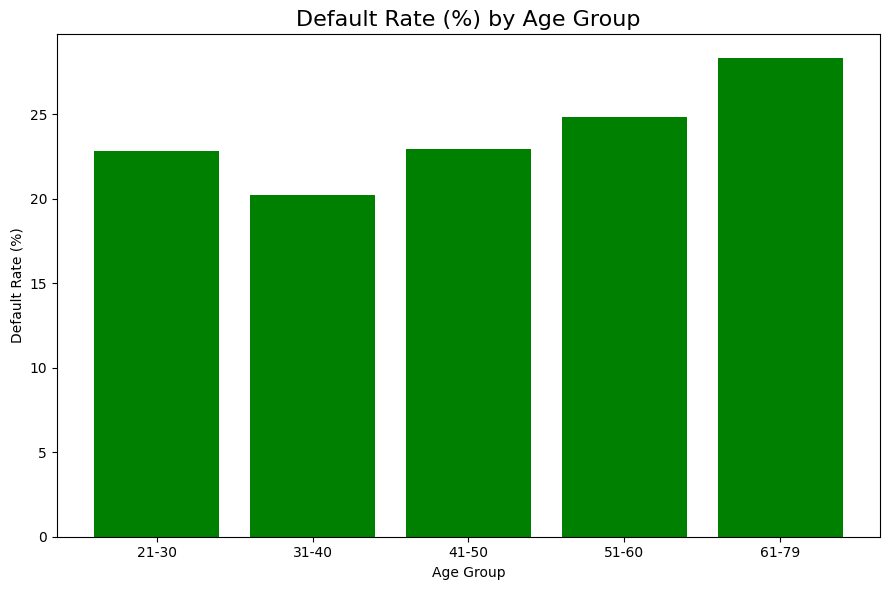

In [159]:
# 3. Default Rate (%) by Age Group


# إنشاء Age Groups
bins = [20, 30, 40, 50, 60, 80]
labels = ['21-30', '31-40', '41-50', '51-60', '61-79']

data['Age_Group'] = pd.cut(
    data['AGE'],
    bins=bins,
    labels=labels,
    right=False
)

# حساب Default Rate
age_default_rate = (
    data.groupby('Age_Group', observed=False)[target]
    .mean() * 100
)

plt.figure(figsize=(9, 6))

bars = plt.bar(
    age_default_rate.index.astype(str),
    age_default_rate.values,
    color='green'
)

plt.title('Default Rate (%) by Age Group', fontsize=16)
plt.xlabel('Age Group')
plt.ylabel('Default Rate (%)')



plt.tight_layout()
plt.show()

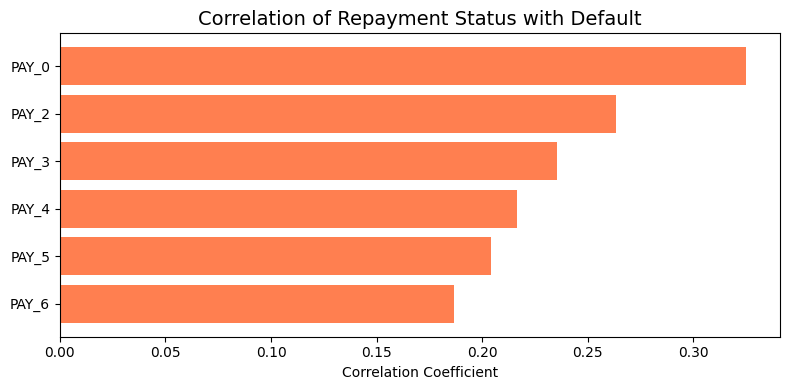

In [160]:
# ارتباط حالات السداد بالتعثر
pay_columns = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
correlations = data[pay_columns + [target]].corr()[target].drop(target).sort_values()

plt.figure(figsize=(8, 4))
plt.barh(correlations.index, correlations.values, color='coral')
plt.title('Correlation of Repayment Status with Default', fontsize=14)
plt.xlabel('Correlation Coefficient')
plt.tight_layout()
plt.show()

In [161]:
df_fe = data.copy()

# 1. نسبة استغلال الحد الائتماني (Credit Utilization) في آخر 3 أشهر
df_fe['UTILIZATION_1'] = df_fe['BILL_AMT1'] / (df_fe['LIMIT_BAL'] + 1)
df_fe['UTILIZATION_2'] = df_fe['BILL_AMT2'] / (df_fe['LIMIT_BAL'] + 1)


In [162]:
# 2. نسبة السداد إلى الفاتورة السابقة (Payment to Bill Ratio)
df_fe['PAY_RATIO_1'] = df_fe['PAY_AMT1'] / (df_fe['BILL_AMT2'].abs() + 1)

In [163]:
# 3. إجمالي عدد أشهر التأخر في السداد لجميع الأشهر الستة
df_fe['TOTAL_DELAY_MONTHS'] = (df_fe[pay_columns] > 0).sum(axis=1)

In [164]:
# 4. التغير في رصيد الفاتورة بين الشهر الأخير والشهر الذي قبله
df_fe['BILL_DIFF'] = df_fe['BILL_AMT1'] - df_fe['BILL_AMT2']

In [165]:
num_features = [
    'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6',
    'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
    'LIMIT_BAL', 'AGE',
    'UTILIZATION_1', 'UTILIZATION_2', 'PAY_RATIO_1', 'TOTAL_DELAY_MONTHS', 'BILL_DIFF'
]

cat_features = ['SEX', 'EDUCATION', 'MARRIAGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

In [166]:
X = df_fe[num_features + cat_features]
y = df_fe[target]

In [167]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [168]:
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features)
])

In [169]:
print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Training set shape: (24000, 28)
Testing set shape: (6000, 28)


In [170]:
pipeline_rf = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=150,
        max_depth=10,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

print("Training the Random Forest model...")
pipeline_rf.fit(X_train, y_train)
print("Training Complete!")

Training the Random Forest model...
Training Complete!


In [172]:
y_pred = pipeline_rf.predict(X_test)
y_proba = pipeline_rf.predict_proba(X_test)[:, 1]

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=['No Default (0)', 'Default (1)']))


--- Classification Report ---
                precision    recall  f1-score   support

No Default (0)       0.88      0.84      0.86      4673
   Default (1)       0.50      0.58      0.54      1327

      accuracy                           0.78      6000
     macro avg       0.69      0.71      0.70      6000
  weighted avg       0.79      0.78      0.79      6000



In [173]:
roc_auc = roc_auc_score(y_test, y_proba)
print(f"ROC-AUC Score: {roc_auc:.4f}")

ROC-AUC Score: 0.7780


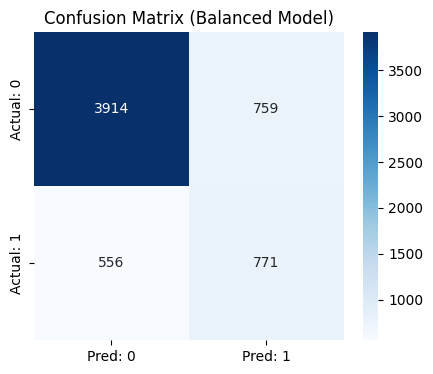

In [174]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred: 0', 'Pred: 1'],
            yticklabels=['Actual: 0', 'Actual: 1'])
plt.title("Confusion Matrix (Balanced Model)")
plt.show()

In [175]:
rf_model = pipeline_rf.named_steps['classifier']
encoded_cats = pipeline_rf.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(cat_features)
all_feature_names = np.array(num_features + list(encoded_cats))
importances = rf_model.feature_importances_

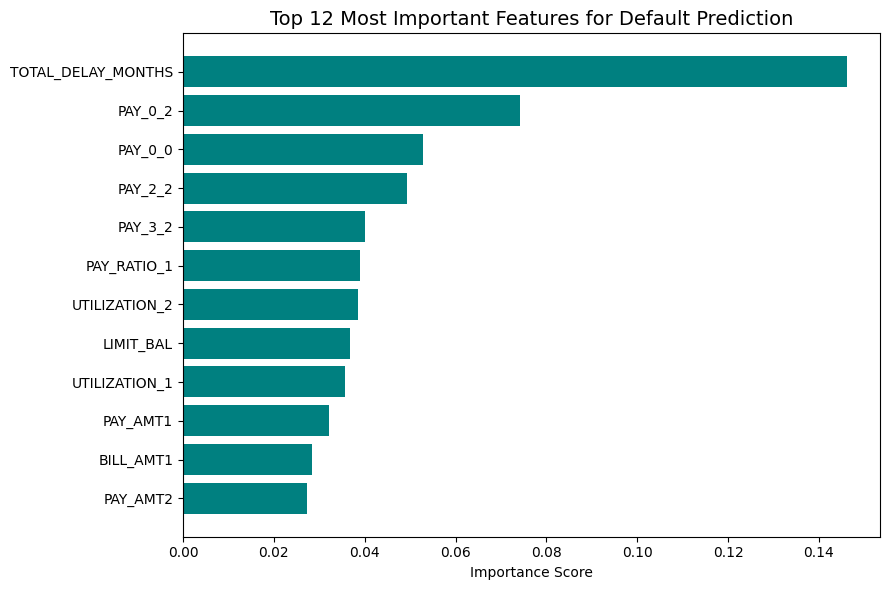

In [176]:
top_indices = np.argsort(importances)[-12:]

plt.figure(figsize=(9, 6))
plt.barh(all_feature_names[top_indices], importances[top_indices], color='teal')
plt.title("Top 12 Most Important Features for Default Prediction", fontsize=14)
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

In [177]:
accuracy = accuracy_score(y_test, y_pred)*100
print(f"Model Accuracy: {accuracy:.2f}")

Model Accuracy: 78.08


In [179]:
predictions = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
print(predictions.head())

       Actual  Predicted
6907        0          0
24575       0          0
26766       0          0
2156        1          0
3179        0          0
